<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [17]:
import pandas as pd
taxi = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

taxi[["fare_amount", "tip_amount", "tolls_amount", "total_amount"]].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [18]:
# Your code here
print(taxi.loc[taxi["trip_distance"].idxmax(), ["fare_amount","tip_amount", "tolls_amount", 'total_amount']])

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object


<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [19]:
meteorite = pd.read_csv("data/Meteorite_Landings.csv")
meteorite = meteorite.iloc[:, :7]
meteorite = meteorite.rename(columns={'mass (g)': 'mass'})
meteorite = meteorite.sort_values(by= 'mass', ascending=False)
meteorite


,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM
...,...,...,...,...,...,...,...
38282,Wei-hui-fu (a),24231,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38283,Wei-hui-fu (b),24232,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38285,Weiyuan,24233,Valid,Mesosiderite,NaN,Found,01/01/1978 12:00:00 AM
41472,Yamato 792768,28117,Valid,CM2,NaN,Found,01/01/1979 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [20]:
import numpy as np
meteorite = pd.read_csv("data/Meteorite_Landings.csv")
meteorite = meteorite.iloc[:, :7]
meteorite = meteorite.rename(columns={'mass (g)': 'mass'})
meteorite = meteorite.sort_values(by= 'mass', ascending=False)
meteorite['year'] = meteorite.year.str.slice(start=6, stop=10)
meteorite['year'] = pd.to_numeric(meteorite['year'], errors='coerce')
meteorite['pre1970'] = np.where(meteorite['year'] < 1970, 1, 0)
meteorite = meteorite.set_index('id')
meteorite = meteorite.sort_index()
meteorite_subset = meteorite.loc[10036:10040]
meteorite_subset

,name,nametype,recclass,mass,fall,year,pre1970
id,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,1
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,1
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,0
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,1


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [21]:
NAs = meteorite[meteorite['year'].isnull()]
NAs

,name,nametype,recclass,mass,fall,year,pre1970
id,,,,,,,
2344,Asarco Mexicana,Valid,"Iron, IIIAB",NaN,Found,NaN,0
4902,Aus,Valid,L,30.2,Found,NaN,0
5012,Benares (b),Valid,Iron,NaN,Found,NaN,0
5191,Cacilandia,Valid,H6,NaN,Found,NaN,0
5199,California,Valid,"Iron, IAB-sLL",NaN,Found,NaN,0
...,...,...,...,...,...,...,...
56528,Jiddat al Harasis 796,Valid,L5,22.8,Found,NaN,0
56529,Jiddat Arkad 003,Valid,L5,148.0,Found,NaN,0
56530,Jiddat al Harasis 797,Valid,L5,249.0,Found,NaN,0


There's a meteorite that was reportedly found in the future:

In [22]:
Future = meteorite[meteorite['year'] > 2025]
Future


,name,nametype,recclass,mass,fall,year,pre1970
id,,,,,,,
57150,Northwest Africa 7701,Valid,CK6,55.0,Found,2101.0,0


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [23]:
taxi = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")
taxi['hour'] = taxi.tpep_dropoff_datetime.str.slice(start=11, stop=13)

taxi_stats = taxi.groupby('hour').agg({
    'trip_distance': 'sum',
    'fare_amount': 'sum',
    'tolls_amount': 'sum',
    'tip_amount': 'sum',
})
taxi_stats = taxi_stats.sort_values(by= 'tip_amount', ascending=False)
taxi_stats.head()

,trip_distance,fare_amount,tolls_amount,tip_amount
hour,,,,
16,10715.39,68013.76,699.04,12249.32
17,16060.31,70160.91,4044.04,12044.03
18,3104.56,11565.56,1454.67,1907.64
15,68.95,461.50,6.12,75.10
19,98.59,268.00,24.48,25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

travelers    Axes(0.125,0.11;0.775x0.77)
dtype: object

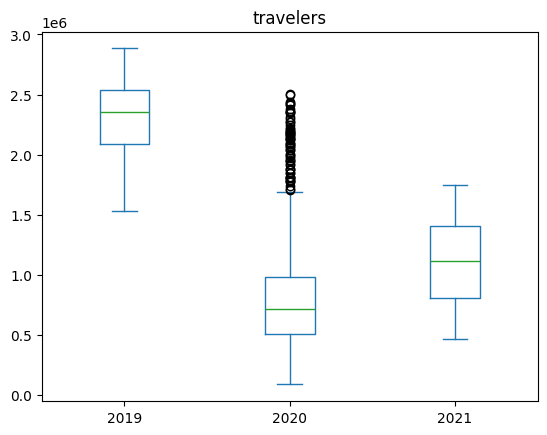

In [24]:
TSA = pd.read_csv("data/tsa_melted_holiday_travel.csv")
TSA.plot(column='travelers', by='year', kind = 'box')

<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

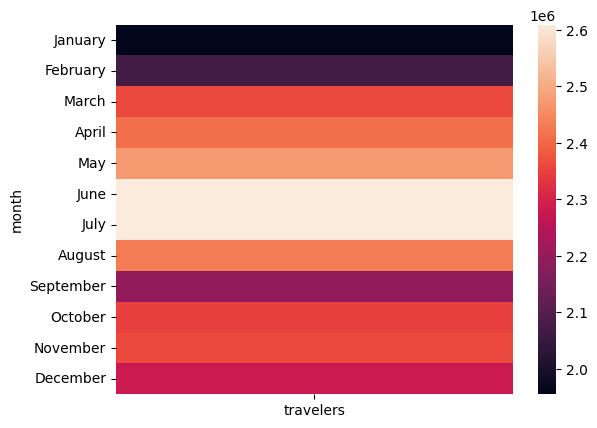

In [25]:
import pandas as pd
import seaborn as sns
TSA['date'] = pd.to_datetime(TSA['date'])

    # Filter for the year 2019
TSA2019 = TSA[TSA['date'].dt.year == 2019].copy()

# Extract month and day of the week names
TSA2019['month'] = TSA2019['date'].dt.month_name()
TSA2019['day_of_week'] = TSA2019['date'].dt.day_name()


TSA2019_stats_mo = TSA2019.groupby('month').agg({
    'travelers': 'median'
})

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

TSA2019_stats_mo = TSA2019_stats_mo.reindex(months_order, axis=0)

TSA2019_stats_dow = TSA2019.groupby('day_of_week').agg({
    'travelers': 'median'
})
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

TSA2019_stats_dow = TSA2019_stats_dow.reindex(days_order, axis=0)


heatmap = sns.heatmap(
        TSA2019_stats_mo)


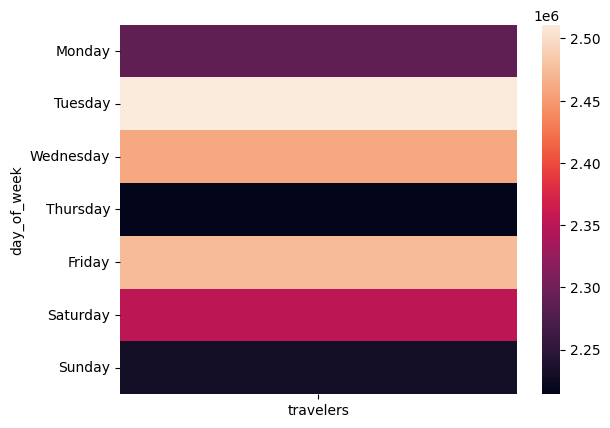

In [26]:
heatmap = sns.heatmap(
        TSA2019_stats_dow)